In [145]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix 

In [115]:
#Loading dataset
df = pd.read_csv("improved_disease_dataset.csv")
disease_data = df

In [116]:
disease_data.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,Paralysis (brain hemorrhage)
1,0,0,1,0,0,0,1,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,0,1,1,0,0,Paralysis (brain hemorrhage)
3,0,0,1,1,1,0,1,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,0,0,0,1,1,Paralysis (brain hemorrhage)


In [117]:
disease_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   fever        2000 non-null   int64 
 1   headache     2000 non-null   int64 
 2   nausea       2000 non-null   int64 
 3   vomiting     2000 non-null   int64 
 4   fatigue      2000 non-null   int64 
 5   joint_pain   2000 non-null   int64 
 6   skin_rash    2000 non-null   int64 
 7   cough        2000 non-null   int64 
 8   weight_loss  2000 non-null   int64 
 9   yellow_eyes  2000 non-null   int64 
 10  disease      2000 non-null   object
dtypes: int64(10), object(1)
memory usage: 172.0+ KB


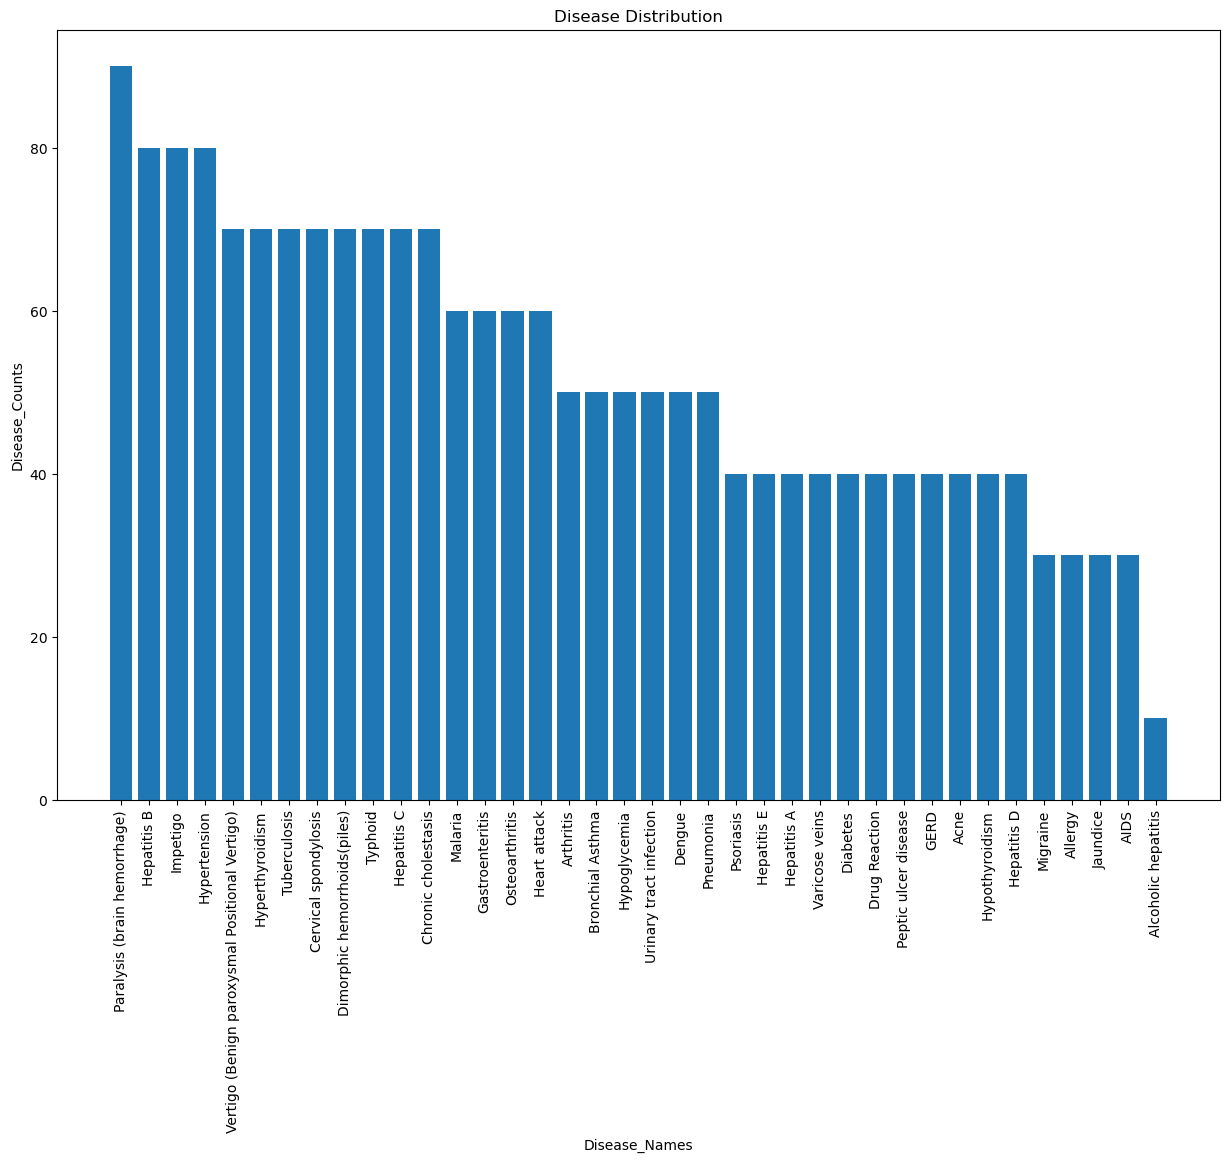

In [118]:
#Plotting a bar graph to show the count of various disease present in the dataset
diseases = disease_data['disease'].value_counts()
names = diseases.index.to_list()
counts = diseases.values.tolist()
#print(names)
plt.figure(figsize=(15,10))
plt.bar(names,counts)
plt.xlabel('Disease_Names')
plt.xticks(rotation=90)
plt.ylabel('Disease_Counts')
plt.title("Disease Distribution")
plt.show()


In [127]:
#Label Encoding target variable
label_enc = LabelEncoder()
disease_data['disease']=label_enc.fit_transform(disease_data['disease'])

In [139]:
# Train-test spilt
X_train,X_test,y_train,y_test = train_test_split(disease_data.iloc[:,:-1],disease_data.iloc[:,-1],random_state=42,test_size=0.2)

In [141]:
# Since the dataset is imbalanced we are going to use RandomOverSampler to create samples of all data samples except the majority class on our training dataset
ros= RandomOverSampler(sampling_strategy='auto',random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

In [143]:
#Before And After Resampling - There has been an increase of 71.5% on the original dataset
print("X_train Before Resampling {}".format(X_train.shape))
print("X_train After Resampling {}".format(X_train_res.shape))
print("y_train Before Resampling {}".format(y_train.shape))
print("y_train After Resampling {}".format(y_train_res.shape))

X_train Before Resampling (1600, 10)
X_train After Resampling (2774, 10)
y_train Before Resampling (1600,)
y_train After Resampling (2774,)


In [151]:
#Training models and finding best parameters
models_params = [(LogisticRegression(),{'C':[0.01,0.1,1,10,100],'solver':['lbfgs','sag']}),
                 (SVC(),{'C': [0.1, 1, 10, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 'kernel': ['rbf']}),
                 (DecisionTreeClassifier(),{'criterion':['gini','entropy']})]

In [157]:
for model , params in models_params:
    gs = GridSearchCV(model , params , cv=4)
    gs.fit(X_train_res,y_train_res)
    print("Best Parameters for {} is {}".format(model,gs.best_params_))
    print("Best Estimator for {} is {}".format(model,gs.best_estimator_))
    y_pred = gs.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("-------------------------------------------------------------------------------------------------")

C:\Users\shind\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\shind\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\shind\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\shind\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Parameters for LogisticRegression() is {'C': 0.1, 'solver': 'lbfgs'}
Best Estimator for LogisticRegression() is LogisticRegression(C=0.1)
              precision    recall  f1-score   support

           0       0.42      0.83      0.56         6
           1       0.36      0.40      0.38        10
           2       0.00      0.00      0.00         1
           3       0.50      0.56      0.53         9
           4       0.10      0.11      0.11         9
           5       0.27      0.43      0.33         7
           6       0.14      0.12      0.13         8
           7       0.58      0.41      0.48        17
           8       0.12      0.33      0.17         6
           9       0.60      0.27      0.38        11
          10       0.69      0.65      0.67        17
          11       0.36      0.62      0.45         8
          12       0.50      0.40      0.44        10
          13       0.43      0.33      0.38         9
          14       0.56      0.64      0.60   